<a href="https://colab.research.google.com/github/suryavedula/agentic_ai_kgp/blob/copilot%2Fweekly-learning/Copy_of_Lecture_1_tutorial_classification_task_tutorial_and_DIY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Prediction using scikit-learn #

![breast cancer detection image](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41598-024-57740-5/MediaObjects/41598_2024_57740_Fig1_HTML.png)

Problem - Breast cancer prediction is a binary classification problem where the goal is to determine whether a tumor is malignant (cancerous) or benign (non-cancerous) based on measurable characteristics of cell nuclei obtained from medical imaging or biopsies.


sklearn datasets - https://scikit-learn.org/stable/api/sklearn.datasets.html

## Import required libraries ##

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Loading the breast cancer data ##

In [ ]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape:", X.shape)

Shape: (569, 30)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Part-1 : Classification using Logistic Regression ##

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))  # Overall percentage of correct predictions

print("\nConfusion Matrix:") # Display confusion matrix header
print(confusion_matrix(y_test, y_pred)) # Show TP, TN, FP, FN counts

print("\nClassification Report:") # Display detailed metrics header
print(classification_report(y_test, y_pred)) # Show precision, recall, F1-score, support


Accuracy: 0.9736842105263158

Confusion Matrix:
[[41  2]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



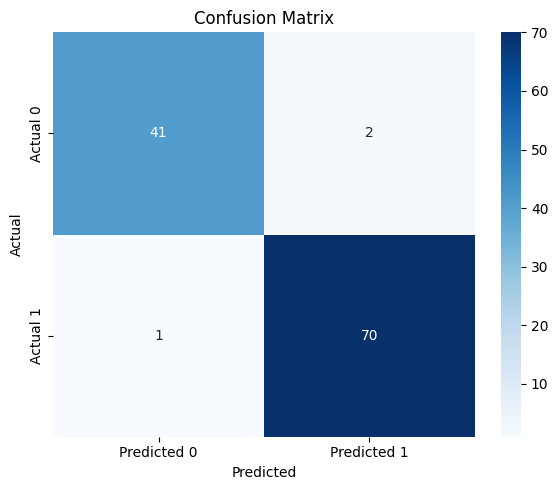

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Do-It-Yourself (DIY) ##

So far, we explored Logistic Regression. It assumes linear decision boundary and simple relationships.

But real-world data is often Non-linear, Noisy and Complex

This raises a question: Can we build better classifiers using other algorithms?

## Part - 2 (DIY) ##

Lets explore how we can implement the other ML Classification algorithms, namely

  1. K-Nearest Neighbors - https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
  2. Decision Tree Classifier - https://scikit-learn.org/stable/modules/tree.html
  3. Support Vector Machines - https://scikit-learn.org/stable/modules/svm.html




## Part - 2a : KNN ##

In [ ]:
# Import KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  # Initialize model with k=5

In [ ]:
# Train model
knn.fit(X_train, y_train)

In [ ]:
# Predict and evaluate
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

print("
Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("
Classification Report:")
print(classification_report(y_test, y_pred_knn))

## Part - 2b : Decision Tree Classifier ##

In [ ]:
# Import Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)  # Initialize model

In [ ]:
# Train model
dt.fit(X_train, y_train)

In [ ]:
# Predict and evaluate
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("
Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("
Classification Report:")
print(classification_report(y_test, y_pred_dt))

## Part - 2c : SVM ##

In [ ]:
# Import SVM
from sklearn.svm import SVC

svm = SVC(kernel="rbf", random_state=42)  # Initialize model with RBF kernel

In [ ]:
# Train model
svm.fit(X_train, y_train)

In [ ]:
# Predict and evaluate
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("
Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("
Classification Report:")
print(classification_report(y_test, y_pred_svm))